In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import os

In [ ]:
# Years to analyze
years = list(range(1980, 2021))
print(len(years))
print(years)

41
[1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]


# Load selected indexes

In [ ]:
# load dic
load_dic = np.load("./selection_idx_part1.npy", allow_pickle=True).item()

# Load PCA resutls

In [4]:
pca_result = pd.read_csv(f"./Part1_pca_result.txt", sep="\t")
print(pca_result.shape)
pca_result.head()

(46000, 12)


,PC1,PC2,PC3,PC4,PC5,PMID,Year,journal,corresponding_countries,Title,ASJC_1st,Subject_area_1st
0,-0.052727,0.018738,-0.150800,-0.099476,-0.267547,7431027,1980,"Journal of neurology, neurosurgery, and psychi...",NaN,"Journal of neurology, neurosurgery, and psychi...",Surgery,Health Sciences
1,0.151673,-0.116654,-0.129296,0.123304,-0.179218,6995820,1980,Medical hypotheses,NaN,Medical hypotheses,Medicine,Health Sciences
2,-0.153047,-0.107056,-0.012100,-0.306701,-0.129546,7448697,1980,Cancer,NaN,Cancer,Cancer Research,Life Sciences
3,0.278895,0.049043,0.097265,-0.126300,-0.152348,11219864,1980,Carcinogenesis,NaN,Carcinogenesis,Cancer Research,Life Sciences
4,-0.024570,-0.257223,-0.239953,0.100530,0.046187,6779220,1980,Neurology,NaN,Neurology,Neurology (clinical),Health Sciences


# Load tSNE results

In [5]:
tsne_result = pd.read_csv(f"./Part1_tsne_result.txt", sep="\t")
print(tsne_result.shape)
tsne_result.head()

(46000, 9)


,tSNE1,tSNE2,PMID,Year,journal,corresponding_countries,Title,ASJC_1st,Subject_area_1st
0,-27.704924,23.642826,7431027,1980,"Journal of neurology, neurosurgery, and psychi...",NaN,"Journal of neurology, neurosurgery, and psychi...",Surgery,Health Sciences
1,18.297745,35.370820,6995820,1980,Medical hypotheses,NaN,Medical hypotheses,Medicine,Health Sciences
2,0.353476,-75.841600,7448697,1980,Cancer,NaN,Cancer,Cancer Research,Life Sciences
3,32.061660,-0.633918,11219864,1980,Carcinogenesis,NaN,Carcinogenesis,Cancer Research,Life Sciences
4,-39.023907,53.432934,6779220,1980,Neurology,NaN,Neurology,Neurology (clinical),Health Sciences


In [6]:
TopNs = 10
ASJC_TopNs = pca_result.ASJC_1st.value_counts().head(TopNs).index.to_list()
ASJC_TopNs

['Medicine',
 'Biochemistry',
 'Surgery',
 'Molecular Biology',
 'Multidisciplinary',
 'Pharmacology',
 'Genetics',
 'Cardiology and Cardiovascular Medicine',
 'Radiology',
 'Public Health']

# Visualize `tSNE` 2D Map

In [7]:
DIR = "./"

cmd = f"mkdir -p {DIR}/figures"
os.system(cmd)

0

## ASJC subkect area 1st

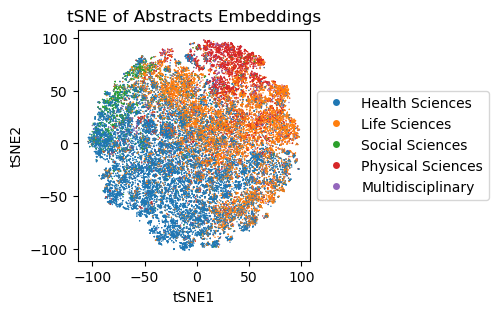

In [8]:
plt.figure(figsize=(3, 3))

sns.scatterplot(
    data=tsne_result,
    x="tSNE1",
    y="tSNE2",
    hue="Subject_area_1st",
    s=1,
    alpha=1,
    linewidth=0.0,
)
plt.title("tSNE of Abstracts Embeddings")
# put labels outside of the plot
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), markerscale=5)
plt.show()

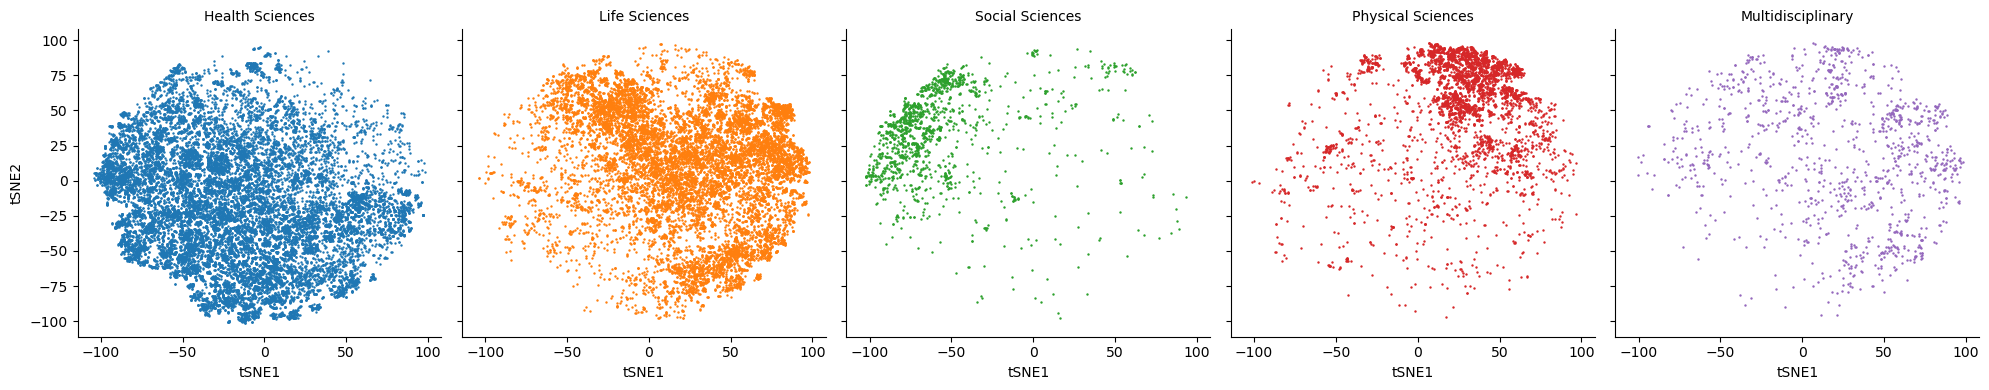

In [10]:
# facet by Subject_area_1st.
g = sns.FacetGrid(
    tsne_result, col="Subject_area_1st", col_wrap=5, height=4, hue="Subject_area_1st"
)
g.map_dataframe(sns.scatterplot, x="tSNE1", y="tSNE2", s=3, alpha=1, linewidth=0)
g.set_titles(col_template="{col_name}")
plt.show()

## Subject Annotation

In [14]:
ASJC_target_Subjects = [
    "Medicine",
    "Molecular Biology",
    "Cell Biology",
    "Developmental Biology",
    "Microbiology (medical)",
    "Microbiology",
    "Structural Biology",
    "Immunology and Microbiology",
    "Applied Microbiology and Biotechnology",
    "Immunology and Microbiology (miscellaneous)",
    "Chemistry",
    "Organic Chemistry",
    "Analytical Chemistry",
    "Physical and Theoretical Chemistry",
    "Inorganic Chemistry",
    "Environmental Chemistry",
    "General Chemistry",
    "Electrochemistry",
    "Materials Chemistry",
    "Chemistry (miscellaneous)",
    "Geochemistry and Petrology",
    "Colloid and Surface Chemistry",
    "Process Chemistry and Technology",
    "Biophysics",
    "Atomic and Molecular Physics",
    "Physics and Astronomy",
    "Condensed Matter Physics",
    "Nuclear and High Energy Physics",
    "Physics and Astronomy (miscellaneous)",
    "Astronomy and Astrophysics",
    "Geophysics",
    "Mathematical Physics",
    "Statistical and Nonlinear Physics",
    "Bioengineering",
    "Environmental Engineering",
    "Biomedical Engineering",
    "Electrical and Electronic Engineering",
    "Engineering",
    "Mechanical Engineering",
    "Chemical Engineering",
    "Engineering (miscellaneous)",
    "Industrial and Manufacturing Engineering",
    "Aerospace Engineering",
    "Control and Systems Engineering",
    "Chemical Engineering (miscellaneous)",
    "Nuclear Energy and Engineering",
    "Ocean Engineering",
    "Geotechnical Engineering and Engineering Geology",
    "Energy Engineering and Power Technology",
    "Civil and Structural Engineering",
]

subjects_merge_dict = {
    "Medicine": "Biomedical Science",
    "Molecular Biology": "Biomedical Science",
    "Cell Biology": "Biomedical Science",
    "Developmental Biology": "Biomedical Science",
    "Microbiology (medical)": "Biomedical Science",
    "Microbiology": "Biomedical Science",
    "Structural Biology": "Biomedical Science",
    "Immunology and Microbiology": "Biomedical Science",
    "Applied Microbiology and Biotechnology": "Biomedical Science",
    "Immunology and Microbiology (miscellaneous)": "Biomedical Science",
    "Chemistry": "Chemistry",
    "Organic Chemistry": "Chemistry",
    "Analytical Chemistry": "Chemistry",
    "Physical and Theoretical Chemistry": "Chemistry",
    "Inorganic Chemistry": "Chemistry",
    "Environmental Chemistry": "Chemistry",
    "General Chemistry": "Chemistry",
    "Electrochemistry": "Chemistry",
    "Materials Chemistry": "Chemistry",
    "Chemistry (miscellaneous)": "Chemistry",
    "Geochemistry and Petrology": "Chemistry",
    "Colloid and Surface Chemistry": "Chemistry",
    "Process Chemistry and Technology": "Chemistry",
    "Biophysics": "physics",
    "Atomic and Molecular Physics": "physics",
    "Physics and Astronomy": "physics",
    "Condensed Matter Physics": "physics",
    "Nuclear and High Energy Physics": "physics",
    "Physics and Astronomy (miscellaneous)": "physics",
    "Astronomy and Astrophysics": "physics",
    "Geophysics": "physics",
    "Mathematical Physics": "physics",
    "Statistical and Nonlinear Physics": "physics",
    "Bioengineering": "engineering",
    "Environmental Engineering": "engineering",
    "Biomedical Engineering": "engineering",
    "Electrical and Electronic Engineering": "engineering",
    "Engineering": "engineering",
    "Mechanical Engineering": "engineering",
    "Chemical Engineering": "engineering",
    "Engineering (miscellaneous)": "engineering",
    "Industrial and Manufacturing Engineering": "engineering",
    "Aerospace Engineering": "engineering",
    "Control and Systems Engineering": "engineering",
    "Chemical Engineering (miscellaneous)": "engineering",
    "Nuclear Energy and Engineering": "engineering",
    "Ocean Engineering": "engineering",
    "Geotechnical Engineering and Engineering Geology": "engineering",
    "Energy Engineering and Power Technology": "engineering",
    "Civil and Structural Engineering": "engineering",
}

colors_subjects = (
    list(sns.color_palette("tab10")) + list(sns.color_palette("Dark2"))[4:7]
)

/tmp/ipykernel_1251638/513945435.py:33: UserWarning: The palette list has more values (13) than needed (4), which may not be intended.
  sns.scatterplot(


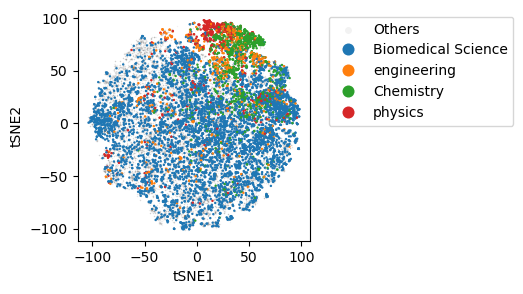

In [17]:
# 1. Define DF for plotting
df_plot_tsne = tsne_result.copy()
df_plot_tsne["Subjects"] = df_plot_tsne.ASJC_1st

df_plot_tsne.loc[df_plot_tsne.Subjects.isin(subjects_merge_dict.keys()), "Subjects"] = (
    df_plot_tsne.loc[
        df_plot_tsne.Subjects.isin(subjects_merge_dict.keys()), "Subjects"
    ].map(subjects_merge_dict)
)
df_plot_tsne.loc[~df_plot_tsne.ASJC_1st.isin(ASJC_target_Subjects), "Subjects"] = (
    "Others"
)

# 2. Split the data into two groups
others = df_plot_tsne[df_plot_tsne["Subjects"] == "Others"]
targets = df_plot_tsne[df_plot_tsne["Subjects"] != "Others"]

plt.figure(figsize=(3, 3))

# 3. Plot "Others" first with a low alpha
sns.scatterplot(
    data=others,
    x="tSNE1",
    y="tSNE2",
    color="gray",
    s=1,
    alpha=0.1,
    linewidth=0,
    label="Others",
)

# 4. Plot the "Target" diseases on top with full alpha
sns.scatterplot(
    data=targets,
    x="tSNE1",
    y="tSNE2",
    hue="Subjects",
    s=3,
    alpha=1.0,
    linewidth=0.0,
    palette=colors_subjects,
)

# Optional: Adjust legend position to make it readable
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", markerscale=5)
# save image
plt.savefig("./figures/Fig1_A.png", dpi=150, bbox_inches="tight")

In [18]:
df_plot_tsne.Subjects.value_counts()

Subjects
Others                36975
Biomedical Science     6228
Chemistry              1320
engineering             762
physics                 715
Name: count, dtype: int64

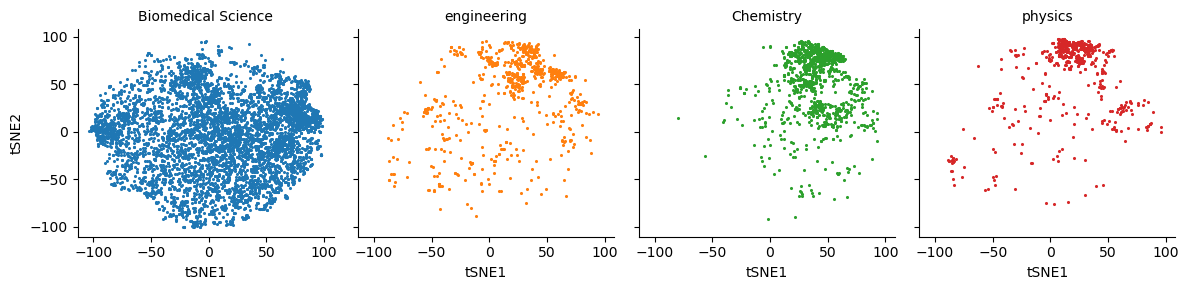

In [19]:
# facet by Subject_area_1st.
g = sns.FacetGrid(
    targets,
    col="Subjects",
    col_wrap=4,
    height=3,
    hue="Subjects",
    palette=colors_subjects,
)
g.map_dataframe(sns.scatterplot, x="tSNE1", y="tSNE2", s=5, alpha=1, linewidth=0.0)
g.set_titles(col_template="{col_name}")
plt.show()

In [21]:
ASJC_target_Subjects = [
    "Radiology",
    "Public Health",
    "Immunology",
    "Developmental Biology",
    "Microbiology (medical)",
    "Microbiology",
    "Chemistry",
    "Atomic and Molecular Physics",
    "Bioengineering",
    "Food Science",
    "Nursing",
    "Genetics (clinical)",
    "Genetics",
    "Molecular Biology",
]


subjects_merge_dict = {
    "Genetics": "Genetics",
    "Genetics (clinical)": "Genetics",
    "Microbiology (medical)": "Microbiology",
    "Microbiology": "Microbiology",
    "Chemistry": "Chemistry",
}

colors_subjects = (
    list(sns.color_palette("tab10")) + list(sns.color_palette("Dark2"))[4:7]
)

/tmp/ipykernel_1251638/829467030.py:34: UserWarning: The palette list has more values (13) than needed (12), which may not be intended.
  sns.scatterplot(


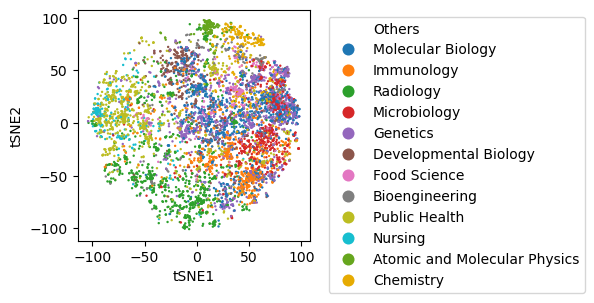

In [22]:
# 1. Define DF for plotting
df_plot_tsne = tsne_result.copy()
df_plot_tsne["Subjects"] = df_plot_tsne.ASJC_1st


df_plot_tsne.loc[df_plot_tsne.Subjects.isin(subjects_merge_dict.keys()), "Subjects"] = (
    df_plot_tsne.loc[
        df_plot_tsne.Subjects.isin(subjects_merge_dict.keys()), "Subjects"
    ].map(subjects_merge_dict)
)
df_plot_tsne.loc[~df_plot_tsne.ASJC_1st.isin(ASJC_target_Subjects), "Subjects"] = (
    "Others"
)

# 2. Split the data into two groups
others = df_plot_tsne[df_plot_tsne["Subjects"] == "Others"]
targets = df_plot_tsne[df_plot_tsne["Subjects"] != "Others"]

plt.figure(figsize=(3, 3))

# 3. Plot "Others" first with a low alpha
sns.scatterplot(
    data=others,
    x="tSNE1",
    y="tSNE2",
    color="gray",
    s=1,
    alpha=0.0,
    linewidth=0,
    label="Others",
)

# 4. Plot the "Target" diseases on top with full alpha
sns.scatterplot(
    data=targets,
    x="tSNE1",
    y="tSNE2",
    hue="Subjects",
    s=3,
    alpha=1.0,
    linewidth=0.0,
    palette=colors_subjects,
)

# Optional: Adjust legend position to make it readable
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", markerscale=5)

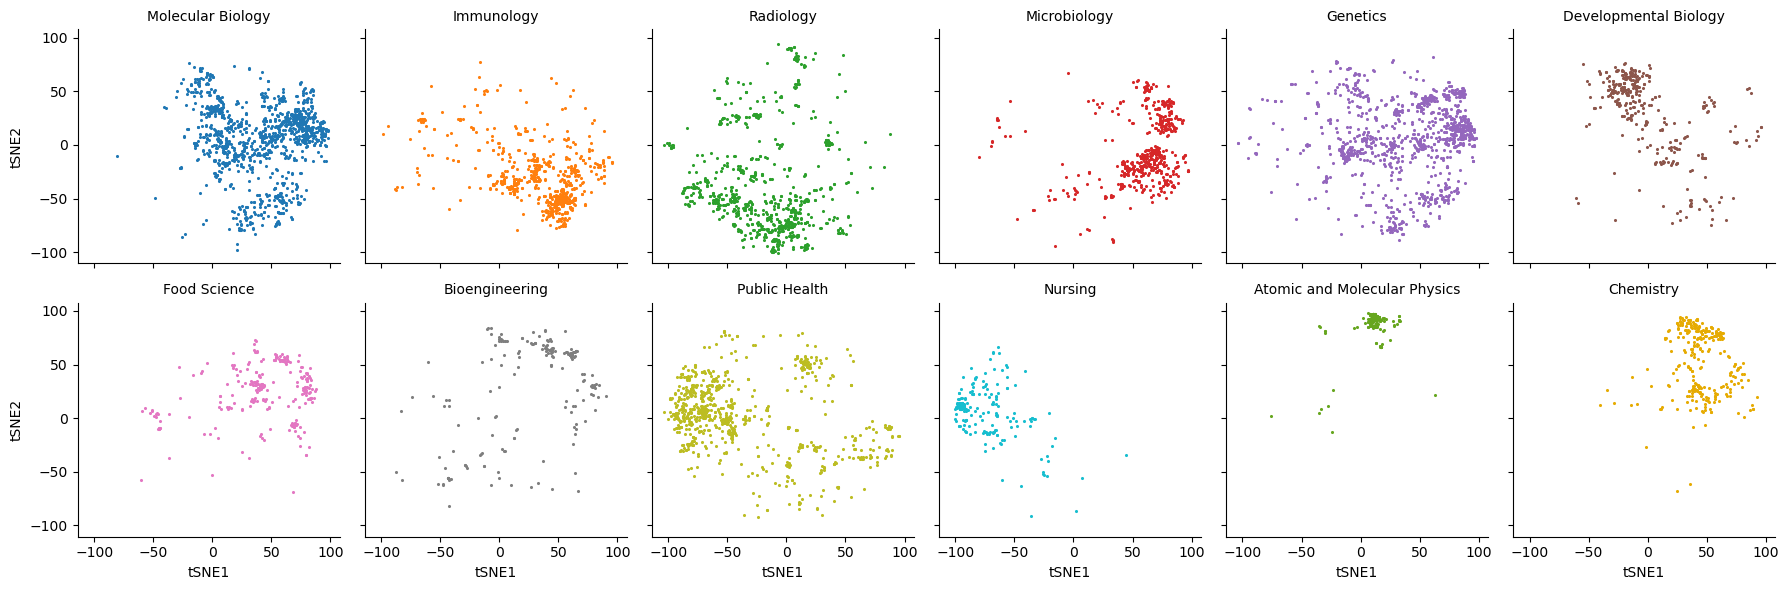

In [23]:
# facet by Subject_area_1st.
g = sns.FacetGrid(
    targets,
    col="Subjects",
    col_wrap=6,
    height=3,
    hue="Subjects",
    palette=colors_subjects,
)
g.map_dataframe(sns.scatterplot, x="tSNE1", y="tSNE2", s=5, alpha=1, linewidth=0.0)
g.set_titles(col_template="{col_name}")
plt.show()

## Disease

In [24]:
ASJC_target_Disease = [
    "Cancer Research",
    "Infectious Diseases",
    "Oncology",
    "Psychiatry and Mental health",
    "Clinical Psychology",
    "Biological Psychiatry",
    "Pshychiatric Mental Health",
    "Dentistry",
    "Gastroenterology",
    "Ophthalmology",
    "Neurology (clinical)" "Neurology",
    "Pulmonary and Respiratory Medicine",
    "Urology",
    "Orthopedics and Sports Medicine",
    "Endocrinology",
    "Immunology and Allergy",
    "Anesthesiology and Pain Medicine",
]

disease_merge_dict = {
    "Cancer Research": "Cancer",
    "Oncology": "Cancer",
    "Infectious Diseases": "Infectious Diseases",
    "Psychiatry and Mental health": "Psychiatry",
    "Clinical Psychology": "Psychiatry",
    "Biological Psychiatry": "Psychiatry",
    "Pshychiatric Mental Health": "Psychiatry",
    "Pulmonary and Respiratory Medicine": "Respiratory",
    "Neurology (clinical)": "Neurology",
    "Neurology": "Neurology",
    "Orthopedics and Sports Medicine": "Orthopedics",
}

colors_disease = (
    list(sns.color_palette("tab10")) + list(sns.color_palette("Dark2"))[2:4]
)

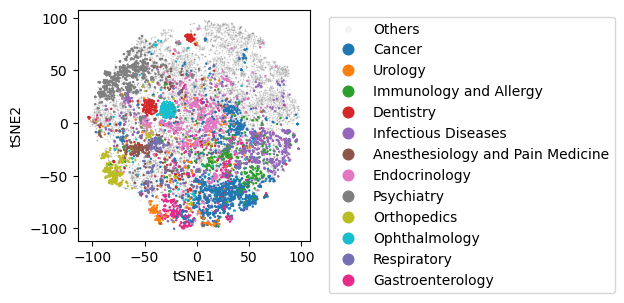

In [25]:
# 1. Define DF for plotting
df_plot_tsne = tsne_result.copy()
df_plot_tsne["Disease"] = df_plot_tsne.ASJC_1st


df_plot_tsne.loc[df_plot_tsne.Disease.isin(disease_merge_dict.keys()), "Disease"] = (
    df_plot_tsne.loc[
        df_plot_tsne.Disease.isin(disease_merge_dict.keys()), "Disease"
    ].map(disease_merge_dict)
)
df_plot_tsne.loc[~df_plot_tsne.ASJC_1st.isin(ASJC_target_Disease), "Disease"] = "Others"


# 2. Split the data into two groups
others = df_plot_tsne[df_plot_tsne["Disease"] == "Others"]
targets = df_plot_tsne[df_plot_tsne["Disease"] != "Others"]

plt.figure(figsize=(3, 3))

# 3. Plot "Others" first with a low alpha
sns.scatterplot(
    data=others,
    x="tSNE1",
    y="tSNE2",
    color="gray",
    s=1,
    alpha=0.1,
    linewidth=0,
    label="Others",
)

# 4. Plot the "Target" diseases on top with full alpha
sns.scatterplot(
    data=targets,
    x="tSNE1",
    y="tSNE2",
    hue="Disease",
    s=3,
    alpha=1.0,
    linewidth=0.0,
    palette=colors_disease,
)

# Optional: Adjust legend position to make it readable
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", markerscale=5)

# save image
plt.savefig("./figures/Fig1_B.png", dpi=150, bbox_inches="tight")

In [26]:
df_plot_tsne.Disease.value_counts()

Disease
Others                              39484
Cancer                               1411
Psychiatry                            840
Endocrinology                         691
Infectious Diseases                   644
Gastroenterology                      428
Respiratory                           420
Orthopedics                           403
Ophthalmology                         373
Immunology and Allergy                370
Anesthesiology and Pain Medicine      325
Dentistry                             310
Urology                               301
Name: count, dtype: int64

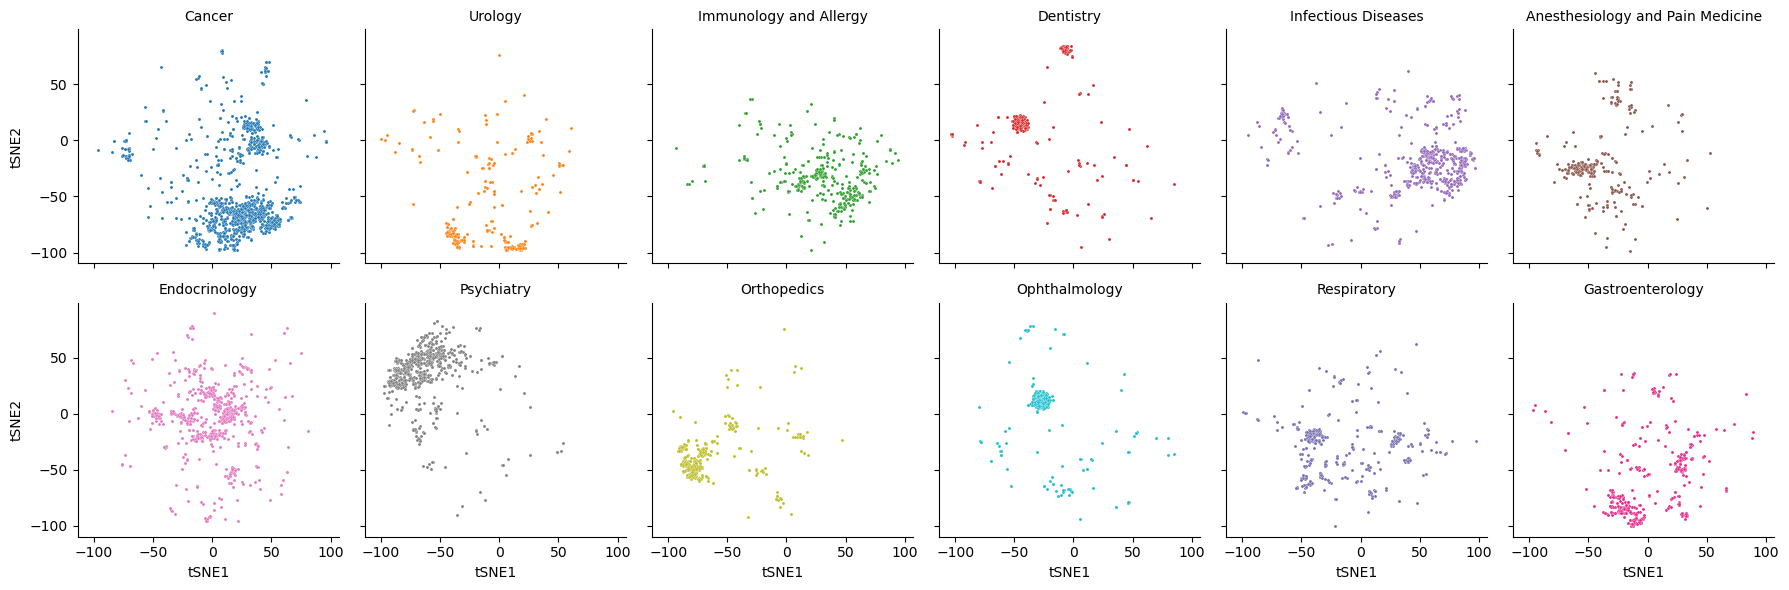

In [27]:
# facet by Subject_area_1st.
g = sns.FacetGrid(
    targets, col="Disease", col_wrap=6, height=3, hue="Disease", palette=colors_disease
)
g.map_dataframe(sns.scatterplot, x="tSNE1", y="tSNE2", s=5, alpha=1)
g.set_titles(col_template="{col_name}")
plt.show()

# Deep-dive in to "Cancer"

In [32]:
df_plot_tsne_cancer = df_plot_tsne.loc[
    df_plot_tsne.ASJC_1st.isin(["Cancer Research", "Oncology", ""]), :
].copy()
print(df_plot_tsne_cancer.shape)
df_plot_tsne_cancer.head()

(1411, 10)


,tSNE1,tSNE2,PMID,Year,journal,corresponding_countries,Title,ASJC_1st,Subject_area_1st,Disease
2,0.353476,-75.841600,7448697,1980,Cancer,NaN,Cancer,Cancer Research,Life Sciences,Cancer
3,32.061660,-0.633918,11219864,1980,Carcinogenesis,NaN,Carcinogenesis,Cancer Research,Life Sciences,Cancer
71,-5.137849,-70.900890,6243509,1980,Cancer,NaN,Cancer,Cancer Research,Life Sciences,Cancer
76,-0.735961,-55.529842,7189690,1980,Cancer,NaN,Cancer,Cancer Research,Life Sciences,Cancer
172,8.897124,-81.531395,7387832,1980,British journal of cancer,NaN,British journal of cancer,Oncology,Health Sciences,Cancer


In [33]:
# Read paper information (For keyword search from paper's Title and Abstract)
DIR_paper = f"{DIR}/DataCollection"
df_paper = []

for year in df_plot_tsne_cancer.Year.unique():
    print(year)
    path = os.path.join(DIR_paper, f"pubmed_data_{year}.tsv")
    if os.path.exists(path):
        df_year = pd.read_csv(
            path,
            sep="\t",
            usecols=["PMID", "title", "abstract"],
        )
        # select only the papers that were selected for embeddings
        df_year = df_year.iloc[df_year.PMID.isin(df_plot_tsne_cancer.PMID)].copy()
        df_paper.append(df_year)
    else:
        print(f"File not found: {path}")

df_paper = pd.concat(df_paper, ignore_index=True)
print(f"Total papers: {len(df_paper)}")

1980
1981
1982
1983
1984
1985
1986
1987
1988
1989
1990
1991
1992
1993
1994
1995
1996
1997
1998
1999
2000
2001
2002
2003
2004
2005
2006
2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025
Total papers: 1411


In [34]:
# Merge the paper information with the tSNE data
df_plot_tsne_cancer_text = df_plot_tsne_cancer.merge(df_paper, on="PMID", how="left")
df_plot_tsne_cancer_text["text"] = (
    df_plot_tsne_cancer_text["title"].fillna("")
    + " "
    + df_plot_tsne_cancer_text["abstract"].fillna("")
)
df_plot_tsne_cancer_text["Year10"] = (df_plot_tsne_cancer_text["Year"] // 10) * 10
df_plot_tsne_cancer_text["Year10"] = (
    df_plot_tsne_cancer_text["Year10"].astype(str) + "s"
)

df_plot_tsne_cancer_text.drop(columns=["title", "abstract"], inplace=True)
print(df_plot_tsne_cancer_text.shape)
df_plot_tsne_cancer_text.head()

(1411, 12)


,tSNE1,tSNE2,PMID,Year,journal,corresponding_countries,Title,ASJC_1st,Subject_area_1st,Disease,text,Year10
0,0.353476,-75.841600,7448697,1980,Cancer,NaN,Cancer,Cancer Research,Life Sciences,Cancer,Results of re-irradiation for cerebral metasta...,1980s
1,32.061660,-0.633918,11219864,1980,Carcinogenesis,NaN,Carcinogenesis,Cancer Research,Life Sciences,Cancer,Studies on a new case of xeroderma pigmentosum...,1980s
2,-5.137849,-70.900890,6243509,1980,Cancer,NaN,Cancer,Cancer Research,Life Sciences,Cancer,Chordoid sarcoma: ultrastructural evidence sup...,1980s
3,-0.735961,-55.529842,7189690,1980,Cancer,NaN,Cancer,Cancer Research,Life Sciences,Cancer,Tobacco-induced changes in oral leukoplakic ep...,1980s
4,8.897124,-81.531395,7387832,1980,British journal of cancer,NaN,British journal of cancer,Oncology,Health Sciences,Cancer,Mortality of wives of men dying with cancer of...,1980s


In [35]:
# find lung casncer-related papers
lung_cancer_regex = (
    r"\b(?:"
    r"lung\s+cancer|"
    r"nsclc|non[-\s]?small\s+cell\s+lung\s+cancer|"
    r"sclc|small\s+cell\s+lung\s+cancer|"
    r"luad|lung\s+adenocarcinoma|"
    r"lusc|lung\s+squamous\s+cell\s+carcinoma"
    r")\b"
)

df_plot_tsne_cancer_text["is_lung"] = df_plot_tsne_cancer_text["text"].str.contains(
    lung_cancer_regex, case=False, na=False
)

df_plot_tsne_cancer_text_lung = df_plot_tsne_cancer_text.loc[
    df_plot_tsne_cancer_text.is_lung, :
].copy()
df_plot_tsne_cancer_text.is_lung.value_counts()

is_lung
False    1332
True       79
Name: count, dtype: int64

In [36]:
# find breast    casncer-related papers
breast_cancer_regex = (
    r"\b(?:"
    r"breast\s+cancer|breast\s+carcinoma|mammary\s+carcinoma|"
    r"tnbc|triple[-\s]?negative\s+breast\s+cancer|"
    r"her2[-\s]?positive\s+breast\s+cancer|"
    r"er[-\s]?positive\s+breast\s+cancer|"
    r"pr[-\s]?positive\s+breast\s+cancer|"
    r"dcis|ductal\s+carcinoma\s+in\s+situ|"
    r"idc|invasive\s+ductal\s+carcinoma|"
    r"ilc|invasive\s+lobular\s+carcinoma"
    r")\b"
)

df_plot_tsne_cancer_text["is_breast"] = df_plot_tsne_cancer_text["text"].str.contains(
    breast_cancer_regex, case=False, na=False
)

df_plot_tsne_cancer_text_breast = df_plot_tsne_cancer_text.loc[
    df_plot_tsne_cancer_text.is_breast, :
].copy()
df_plot_tsne_cancer_text.is_breast.value_counts()

is_breast
False    1237
True      174
Name: count, dtype: int64

In [37]:
# find colon    casncer-related papers
colon_cancer_regex = (
    r"\b(?:"
    r"colon\s+cancer|colorectal\s+cancer|rectal\s+cancer|"
    r"colorectal\s+carcinoma|colon\s+carcinoma|rectal\s+carcinoma|"
    r"crc|"
    r"colon\s+adenocarcinoma|colorectal\s+adenocarcinoma|"
    r"caco|coad|read"
    r")\b"
)

df_plot_tsne_cancer_text["is_colon"] = df_plot_tsne_cancer_text["text"].str.contains(
    colon_cancer_regex, case=False, na=False
)

df_plot_tsne_cancer_text_colon = df_plot_tsne_cancer_text.loc[
    df_plot_tsne_cancer_text.is_colon, :
].copy()
df_plot_tsne_cancer_text.is_colon.value_counts()

is_colon
False    1333
True       78
Name: count, dtype: int64

In [38]:
# find liver    casncer-related papers
liver_cancer_regex = (
    r"\b(?:"
    r"liver\s+cancer|hepatic\s+cancer|"
    r"hepatocellular\s+carcinoma|"
    r"hcc|"
    r"intrahepatic\s+cholangiocarcinoma|"
    r"cholangiocarcinoma|"
    r"hepatic\s+tumou?r|liver\s+tumou?r"
    r")\b"
)

df_plot_tsne_cancer_text["is_liver"] = df_plot_tsne_cancer_text["text"].str.contains(
    liver_cancer_regex, case=False, na=False
)

df_plot_tsne_cancer_text_liver = df_plot_tsne_cancer_text.loc[
    df_plot_tsne_cancer_text.is_liver, :
].copy()
df_plot_tsne_cancer_text.is_liver.value_counts()

is_liver
False    1378
True       33
Name: count, dtype: int64

In [39]:
# find skin    casncer-related papers
skin_cancer_regex = (
    r"\b(?:"
    r"skin\s+cancer|cutaneous\s+melanoma|melanoma|"
    r"basal\s+cell\s+carcinoma|bcc|"
    r"squamous\s+cell\s+carcinoma|cscc|cutaneous\s+squamous\s+cell\s+carcinoma|"
    r"merkel\s+cell\s+carcinoma"
    r")\b"
)

df_plot_tsne_cancer_text["is_skin"] = df_plot_tsne_cancer_text["text"].str.contains(
    skin_cancer_regex, case=False, na=False
)

df_plot_tsne_cancer_text_skin = df_plot_tsne_cancer_text.loc[
    df_plot_tsne_cancer_text.is_skin, :
].copy()
df_plot_tsne_cancer_text.is_skin.value_counts()

is_skin
False    1329
True       82
Name: count, dtype: int64

In [40]:
# find pancreatic   casncer-related papers
pancreatic_cancer_regex = (
    r"\b(?:"
    r"pancreatic\s+cancer|pancreas\s+cancer|"
    r"pancreatic\s+carcinoma|"
    r"pdac|pancreatic\s+ductal\s+adenocarcinoma|"
    r"pancreatic\s+adenocarcinoma|"
    r"pancreatic\s+neoplasm|"
    r"ipmn|intraductal\s+papillary\s+mucinous\s+neoplasm"
    r")\b"
)

df_plot_tsne_cancer_text["is_pancreatic"] = df_plot_tsne_cancer_text[
    "text"
].str.contains(pancreatic_cancer_regex, case=False, na=False)


df_plot_tsne_cancer_text_pancreatic = df_plot_tsne_cancer_text.loc[
    df_plot_tsne_cancer_text.is_pancreatic, :
].copy()
df_plot_tsne_cancer_text.is_pancreatic.value_counts()

is_pancreatic
False    1382
True       29
Name: count, dtype: int64

In [41]:
df_plot_tsne_cancer_text["is_multicancer"] = (
    df_plot_tsne_cancer_text[
        ["is_lung", "is_breast", "is_colon", "is_liver", "is_skin", "is_pancreatic"]
    ].sum(axis=1)
    >= 2
)
df_plot_tsne_cancer_text.is_multicancer.value_counts()

is_multicancer
False    1388
True       23
Name: count, dtype: int64

In [42]:
# label caner type
df_plot_tsne_cancer_text["CancerType"] = "Other"
df_plot_tsne_cancer_text.loc[df_plot_tsne_cancer_text.is_multicancer, "CancerType"] = (
    "Multi-cancer"
)
df_plot_tsne_cancer_text.loc[df_plot_tsne_cancer_text.is_lung, "CancerType"] = "Lung"
df_plot_tsne_cancer_text.loc[df_plot_tsne_cancer_text.is_breast, "CancerType"] = (
    "Breast"
)
df_plot_tsne_cancer_text.loc[df_plot_tsne_cancer_text.is_colon, "CancerType"] = "Colon"
df_plot_tsne_cancer_text.loc[df_plot_tsne_cancer_text.is_liver, "CancerType"] = "Liver"
df_plot_tsne_cancer_text.loc[df_plot_tsne_cancer_text.is_skin, "CancerType"] = "Skin"
df_plot_tsne_cancer_text.loc[df_plot_tsne_cancer_text.is_pancreatic, "CancerType"] = (
    "Pancreatic"
)

df_plot_tsne_cancer_text.CancerType.value_counts()

CancerType
Other         966
Breast        160
Skin           81
Colon          73
Lung           69
Liver          33
Pancreatic     29
Name: count, dtype: int64

(-150.0, 150.0)

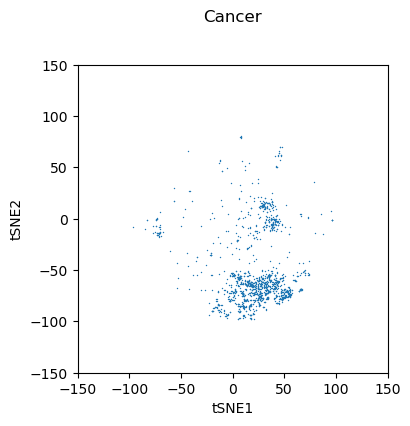

In [43]:
plt.figure(figsize=(4, 4))
sns.scatterplot(
    data=df_plot_tsne_cancer_text,
    x="tSNE1",
    y="tSNE2",
    s=1,
    alpha=1.0,  # Fully opaque
    linewidth=0.0,
)

plt.title("Cancer\n\n")
plt.xlim(-150, 150)
plt.ylim(-150, 150)

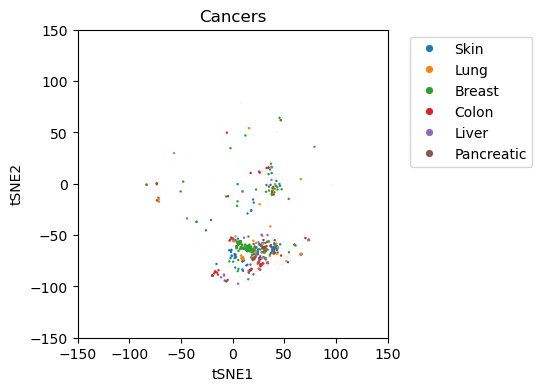

In [56]:
plt.figure(figsize=(4, 4))

sns.scatterplot(
    data=df_plot_tsne_cancer_text.loc[
        df_plot_tsne_cancer_text.CancerType == "Other", :
    ],
    x="tSNE1",
    y="tSNE2",
    color="lightgray",
    s=1,
    alpha=0.1,
    linewidth=0.0,
)


sns.scatterplot(
    data=df_plot_tsne_cancer_text.loc[
        df_plot_tsne_cancer_text.CancerType != "Other", :
    ],
    x="tSNE1",
    y="tSNE2",
    hue="CancerType",
    s=3,
    alpha=1.0,
    linewidth=0.0,
)

plt.title("Cancers")
plt.xlim(-150, 150)
plt.ylim(-150, 150)

# Optional: Adjust legend position to make it readable
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", markerscale=3)

# save image
plt.savefig("./figures/Fig1_C.png", dpi=150, bbox_inches="tight")

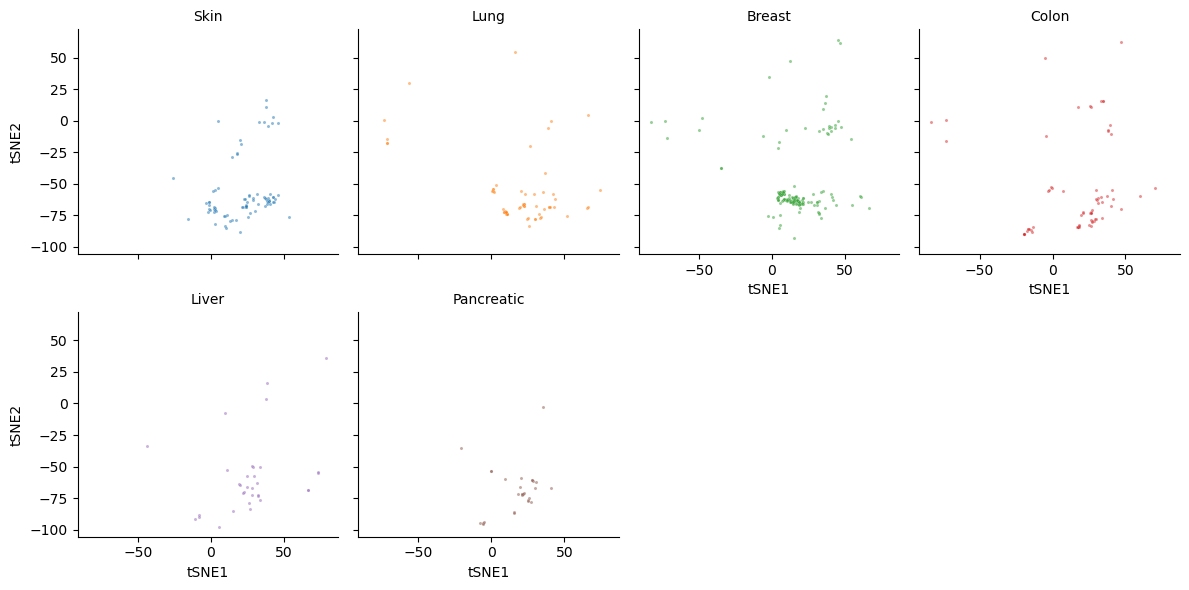

In [45]:
# facet by Subject_area_1st.
g = sns.FacetGrid(
    df_plot_tsne_cancer_text.loc[df_plot_tsne_cancer_text.CancerType != "Other", :],
    col="CancerType",
    col_wrap=4,
    height=3,
    hue="CancerType",
    palette=colors_disease,
)
g.map_dataframe(sns.scatterplot, x="tSNE1", y="tSNE2", s=5, alpha=0.5)
g.set_titles(col_template="{col_name}")
plt.show()

## Omics data in cancer

In [ ]:
# 1.  Genomics

genomics_regex = (
    # 1. The "Omic" and Field definitions
    r"genet(?:e|ic|ics)|"
    r"genom(?:e|ic|ics)|"
    r"whole[- ]genome|whole[- ]exome|"
    r"\bwgs\b|\bwes\b|"
    r"copy\snumber\svariation|\bcnv\b|"
    r"single\snucleotide\spolymorphism|\bsnp\b"
    r"haplotype\smapping|linkage\sdisequilibrium|"
    r"mutational\s(?:landscape|signature|burden|profile)|"
    r"mutation|variant"
)

df_plot_tsne_cancer_text["is_genomics"] = df_plot_tsne_cancer_text["text"].str.contains(
    genomics_regex, case=False, na=False
)

df_plot_tsne_cancer_text.is_genomics.value_counts()

is_genomics
False    1162
True      249
Name: count, dtype: int64

In [47]:
# 2.  Transcriptomics
transcriptomics_regex = (
    r"transcriptome|transcriptomic|transcriptomics|transcript(?:s|al)?|"
    r"rna[-/\s]?seq(?:uencing)?|rnaseq|"
    r"gene\s+expression(?:\s+profil(?:e|ing))?|"
    r"transcriptional\s+profil(?:e|ing)|"
    r"rna\s+profil(?:e|ing)|"
    r"gene\s+expression\s+analysis|"
    r"differential\s+gene\s+expression|"
    r"transcript\s+abundance|"
    r"mrna|messenger\s+rna|"
    r"lncrna|long\s+non[-\s]?coding\s+rna|"
    r"microrna|mirna|"
    r"circrna|circular\s+rna|"
    r"deg(?:s)?"
)


df_plot_tsne_cancer_text["is_transcriptomics"] = df_plot_tsne_cancer_text[
    "text"
].str.contains(transcriptomics_regex, case=False, na=False)

df_plot_tsne_cancer_text.is_transcriptomics.value_counts()

is_transcriptomics
False    1102
True      309
Name: count, dtype: int64

In [ ]:
# 4. Proteomics

proteomics_regex = (
    r"protein|"
    r"proteom(?:e|ics|ic)|"
    r"secretom(?:e|ics)|"
    r"tmt[- ]labeling|itraq|silac|"
    r"label-free\squantification|\blfq\b|"
    r"protein[- ]protein\sinteraction\s(?:map|network)|\bppi\b|"
    r"global\sprotein\sprofiling|"
    r"protein\satlas"
)

df_plot_tsne_cancer_text["is_proteomics"] = df_plot_tsne_cancer_text[
    "text"
].str.contains(proteomics_regex, case=False, na=False)

df_plot_tsne_cancer_text.is_proteomics.value_counts()

is_proteomics
False    1105
True      306
Name: count, dtype: int64

In [50]:
# 5. Merge multo-omics

df_plot_tsne_cancer_text["is_multiomics"] = (
    df_plot_tsne_cancer_text[
        ["is_genomics", "is_transcriptomics", "is_proteomics"]
    ].sum(axis=1)
    >= 2
)

df_plot_tsne_cancer_text["Omics"] = "Other"

df_plot_tsne_cancer_text.loc[df_plot_tsne_cancer_text.is_multiomics, "Omics"] = (
    "Multi-omics"
)

df_plot_tsne_cancer_text.loc[
    (df_plot_tsne_cancer_text.is_genomics) & (~df_plot_tsne_cancer_text.is_multiomics),
    "Omics",
] = "Genomics"

df_plot_tsne_cancer_text.loc[
    (df_plot_tsne_cancer_text.is_transcriptomics)
    & (~df_plot_tsne_cancer_text.is_multiomics),
    "Omics",
] = "Transcriptomics"

df_plot_tsne_cancer_text.loc[
    (df_plot_tsne_cancer_text.is_proteomics)
    & (~df_plot_tsne_cancer_text.is_multiomics),
    "Omics",
] = "Proteomics"

df_plot_tsne_cancer_text.Omics.value_counts()

Omics
Other              791
Multi-omics        213
Proteomics         146
Genomics           135
Transcriptomics    126
Name: count, dtype: int64

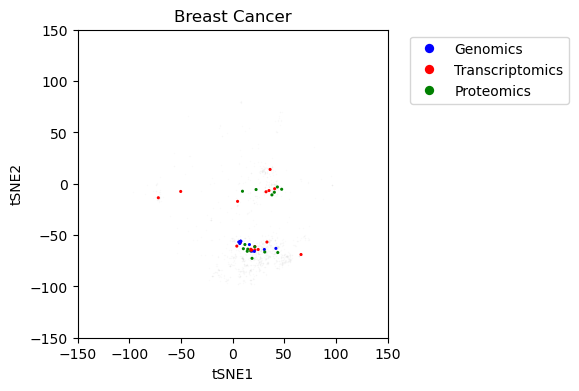

: 

In [ ]:
plt.figure(figsize=(4, 4))

# others coloed in gray, and put it in the back
sns.scatterplot(
    data=df_plot_tsne_cancer_text.loc[
        (df_plot_tsne_cancer_text.CancerType != "Breast")
        | (df_plot_tsne_cancer_text.Omics == "Others"),
        :,
    ],
    x="tSNE1",
    y="tSNE2",
    color="lightgray",
    s=1,
    alpha=0.1,
    linewidth=0.0,
)


sns.scatterplot(
    data=df_plot_tsne_cancer_text.loc[
        (df_plot_tsne_cancer_text.CancerType == "Breast")
        & (
            df_plot_tsne_cancer_text.Omics.isin(
                ["Genomics", "Transcriptomics", "Proteomics"]
            )
        ),
        :,
    ],
    x="tSNE1",
    y="tSNE2",
    hue="Omics",
    s=5,
    alpha=1,
    linewidth=0.0,
    hue_order=["Genomics", "Transcriptomics", "Proteomics"],
    palette={"Genomics": "blue", "Transcriptomics": "red", "Proteomics": "green"},
    # palette=colors_disease,
)

plt.title("Breast Cancer")
plt.xlim(-150, 150)
plt.ylim(-150, 150)

# Optional: Adjust legend position to make it readable
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", markerscale=3)

# save image
plt.savefig("./figures/Fig1_D.png", dpi=150, bbox_inches="tight")